Import de dataset y librerias

In [1]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from skforecast.preprocessing import RollingFeatures

dataset = 'Lorca_processed.csv'
                              
data = pd.read_csv( #Cargar el csv
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

datet = data["datetime"].iloc[int(len(data) * 0.8):] #reservamos las fechas para el dataframe de promedios

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure','month', 'day', 'hour', 'minute'] #variables exogenas


Dividimos en train y test

In [2]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size] #80% train
data_test  = data.iloc[train_size:] #20% test

Escalamos los datos.

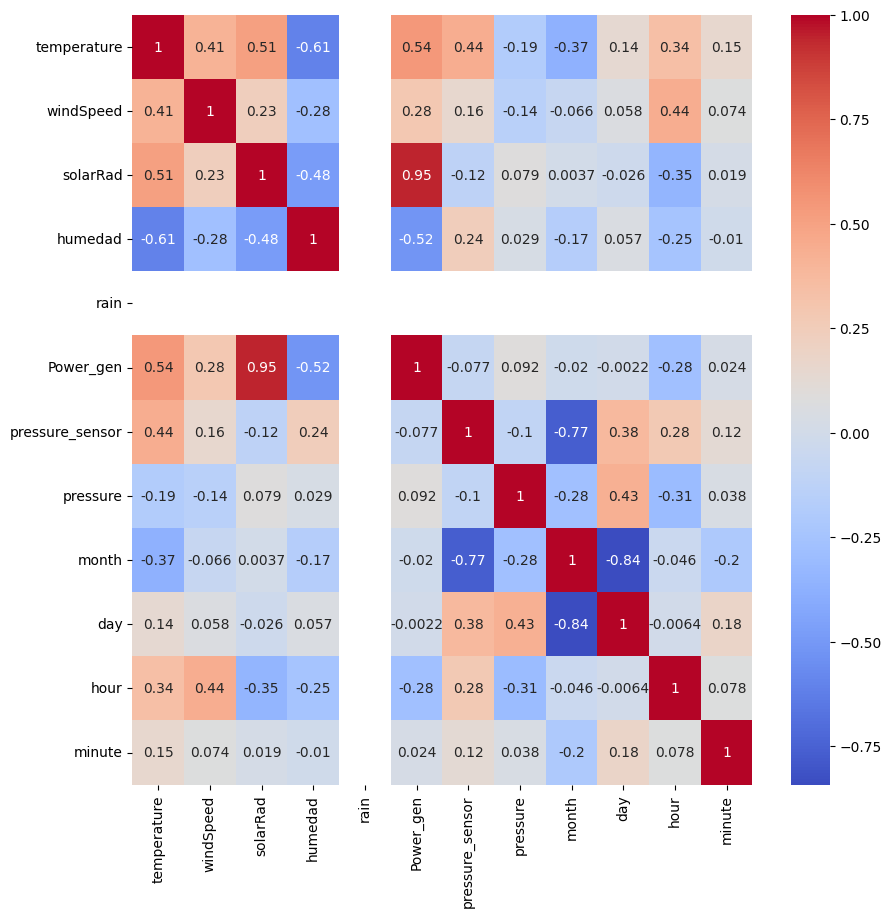

In [ ]:
scaler = MinMaxScaler()
#entrenamiento
train_scaled = data_train.copy()
train_scaled[exogenas] = scaler.fit_transform(data_train[exogenas])

corr_df = train_scaled.corr(method ='spearman')

#test
test_scaled = data_test.copy()
test_scaled[exogenas] = scaler.fit_transform(data_test[exogenas])

corr_df = test_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Evolucion de las variables exogenas

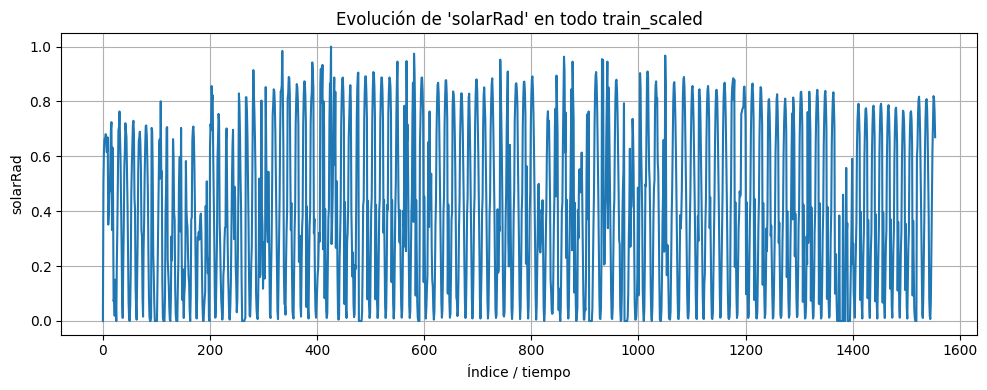

In [ ]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index, train_scaled[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo train_scaled")
plt.grid(True)
plt.tight_layout()
plt.show()


Valores de las exogenas para un dia en concreto

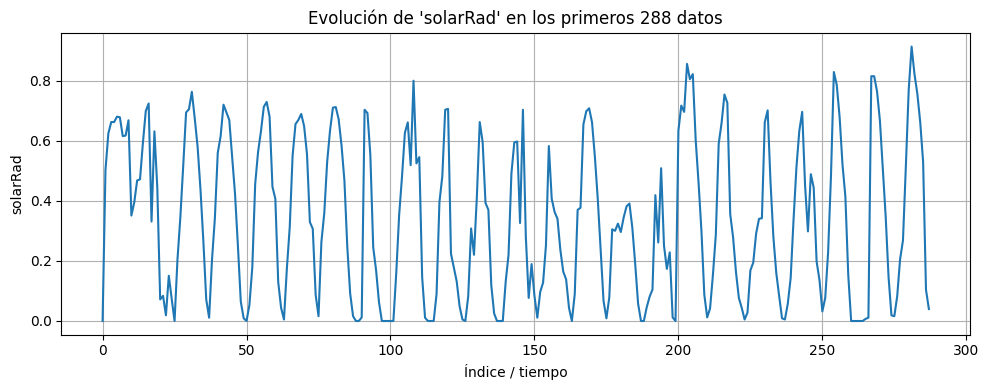

In [ ]:
pasos_dia = (24 * 60 // 5)   #288 primer dia de data_train (datos cada 5 minutos)

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index[:pasos_dia], train_scaled[var].iloc[:pasos_dia])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en los primeros {pasos_dia} datos")
plt.grid(True)
plt.tight_layout()
plt.show()

El primer paso es crear el forecaster.

In [ ]:
window_features = RollingFeatures(
                      stats        = ['mean', 'min', 'max'],
                      window_sizes = [10, 10, 10]
                  ) #media, minimo y maximo de los ultimos 10 valores

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 5, n_estimators = 400, subsample = 0.8),
    lags = 3, #3 valores previos para predecir el actual
    window_features = window_features
)

Entrenamos el forecaster

In [ ]:
X_test, y_test = forecaster.create_train_X_y(y=test_scaled['Power_gen'], exog=test_scaled[exogenas]) #matrices test
X_train, y_train = forecaster.create_train_X_y(y=train_scaled['Power_gen'], exog=train_scaled[exogenas]) #matrices train

forecaster.fit(y=train_scaled['Power_gen'], exog=train_scaled[exogenas]) #entrenar
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [1 2 3] 
Window features: ['roll_mean_10', 'roll_min_10', 'roll_max_10'] 
Window size: 10 
Series name: Power_gen 
Exogenous included: True 
Exogenous names: 
    temperature, solarRad, humedad, windSpeed, rain, pressure, month, day, hour,
    minute 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 1554] 
Training index type: RangeIndex 
Training index frequency: 1 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 5, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 400, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': 0.8, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-02-09 09:27:05 
Last fit date: 2026-02-09 09:27:05 
Skforecast version: 0.20.0 
Python version: 3.14.1 
Forecaster id: None

Comprobamos si hay overfitting. El early_stop = None, por lo que se aplicará sobre los 400 árboles. La reducción del error segun avanza el train indica la efectiva eliminacion de perdidas. Alcanza unaestabilización al final, lo que significa el final del proceso de entrenamiento. El comportamiento del modelo en entrenamiento y validacion es consistente, lo que confirma la no presencia de sobreentrenamiento en los datos.

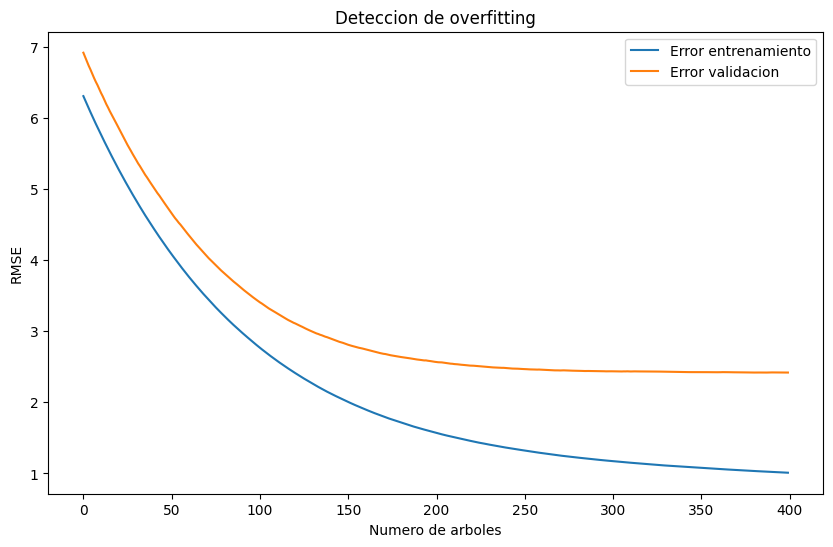

In [ ]:
model  = forecaster.estimator

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)

results = model.evals_result()

plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['rmse'], label='Error entrenamiento')
plt.plot(results['validation_1']['rmse'], label='Error validacion')
plt.xlabel('Numero de arboles')
plt.ylabel('RMSE')
plt.title('Deteccion de overfitting')
plt.legend()
plt.show()

Obtenemos las variables mas importantes en el forecaster

In [ ]:
importancia = forecaster.get_feature_importances()
print(importancia)

         feature  importance
7       solarRad    0.607498
0          lag_1    0.115777
1          lag_2    0.039154
14          hour    0.034735
5    roll_max_10    0.033808
12         month    0.032105
3   roll_mean_10    0.020853
6    temperature    0.020045
4    roll_min_10    0.018897
15        minute    0.016118
2          lag_3    0.015949
8        humedad    0.013851
9      windSpeed    0.011590
13           day    0.010158
11      pressure    0.009463
10          rain    0.000000


Usamos SHAP para crear los datos de entrenamiento

In [ ]:
x_train, y_train = forecaster.create_train_X_y(
    y=train_scaled['Power_gen'],
    exog=train_scaled[exogenas]
)

print(x_train.head()) 
print(y_train.head(3)) 

      lag_1    lag_2    lag_3  roll_mean_10  roll_min_10  roll_max_10  \
10  0.00000  2.30240  4.60480      5.180400          0.0       11.512   
11  2.16275  0.00000  2.30240      5.396675          0.0       11.512   
12  4.32550  2.16275  0.00000      5.541425          0.0       11.512   
13  6.48825  4.32550  2.16275      5.614650          0.0       11.512   
14  8.65100  6.48825  4.32550      5.616350          0.0       11.512   

    temperature  solarRad  humedad  windSpeed  rain  pressure     month  \
10     0.201039  0.351297   0.4250   0.736842   0.0  0.229947  0.166667   
11     0.218372  0.395210   0.4000   0.631579   0.0  0.254902  0.166667   
12     0.218372  0.468064   0.4000   0.736842   0.0  0.233512  0.166667   
13     0.214906  0.472056   0.4125   0.789476   0.0  0.235294  0.166667   
14     0.266897  0.592814   0.3500   0.789476   0.0  0.244207  0.166667   

         day      hour    minute  
10  0.233333  0.391304  0.576271  
11  0.233333  0.391304  0.864407  
12  0

Explainer del SHAP

In [ ]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

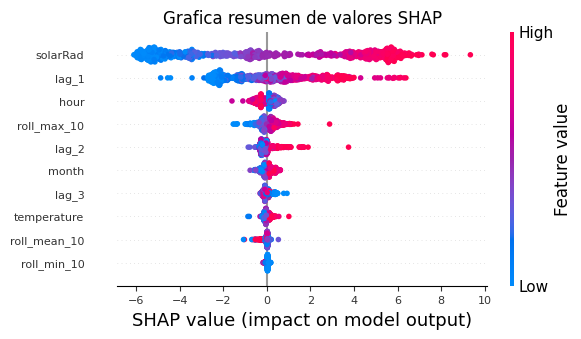

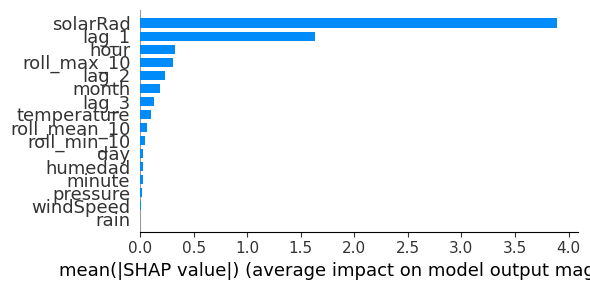

In [ ]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

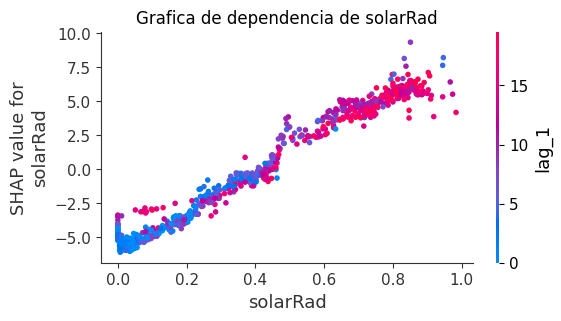

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Ahora veremos las explicaciones de SHAP para predicciones de las proximas 366 muestras (data_test)

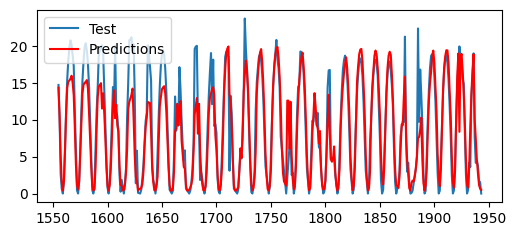

In [ ]:
pred = forecaster.predict(steps=len(test_scaled), exog=test_scaled[exogenas])
fig, ax = plt.subplots(figsize=(6, 2.5))
test_scaled['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-', color='red')
ax.set_xlabel(None)
ax.legend()
plt.show()

Graficas de dependencia parcial.

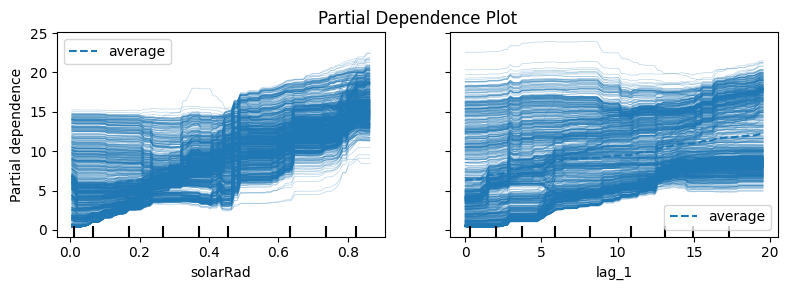

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [ ]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.8853
Mean Squared Error (MSE): 8.1985
Root Mean Squared Error (RMSE): 2.8633
Coeficiente de determinación (R^2): 0.8311


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [ ]:
t_min = data["hour"] * 60 + data["minute"] #minutos desde medianoche
t_day = 24 * 60 #minutos al dia

t_mid = 13 * 60 #mediodia solar
x = abs((t_min - t_mid) / (t_day / 2))   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) #1-x^2 valores [0,1]

IRR_MAX = 1002 #maxima solarRad en el dataset 
train_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm
test_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [ ]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'month', 'day', 'hour', 'minute',
            'irr_ideal'] #irr_ideal añadida a la exogenas

forecaster.fit(y=train_scaled["Power_gen"],
               exog=train_scaled[exogenas]) #volvemos a entrenar

pred = forecaster.predict(steps=len(test_scaled),
                          exog=test_scaled[exogenas]) #volvemos a predecir

Nuevas métricas de la predicción, ligeramente mejores.

In [ ]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}") #MAE = Error medio en la predicción
print(f"Mean Squared Error (MSE): {mse:.4f}") #MSE = Error cuadrático medio en la predicción
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}") #RMSE = Raíz del error cuadrático medio en la predicción
print(f"Coeficiente de determinación (R^2): {r2:.4f}") #R^2 = Coeficiente de determinación

Mean Absolute Error (MAE): 1.7311
Mean Squared Error (MSE): 7.4710
Root Mean Squared Error (RMSE): 2.7333
Coeficiente de determinación (R^2): 0.8461


Comparativa realidad vs prediccion

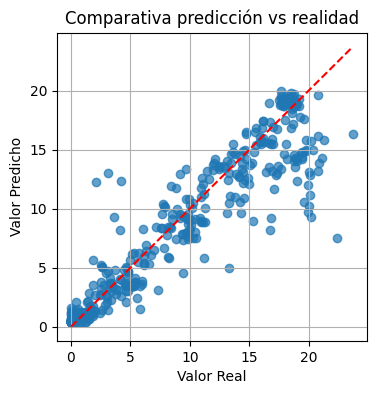

In [ ]:
plt.figure(figsize=(4, 4))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()

Tratamiento de ceros

In [ ]:
error_cero = np.where((y_test == 0) & (pred > mae))[0]

print(f"Se encontraron {len(error_cero)} errores mayores que el mae sen el valor cero")

print(pred.iloc[error_cero])

Se encontraron 0 errores mayores que el mae sen el valor cero
Series([], Name: pred, dtype: float64)


Cálculo de medias mañana, tarde y diaria.

In [ ]:
pred_clas = pd.DataFrame({
    'datetime': datet,
    'prediction': pred.values
})

h = pred_clas['datetime'].dt.hour
condiciones = [(h >= 7) & (h < 13), (h >= 13) & (h < 20)] #[7,13) mañana, [13,20) tarde
elecciones = ['mañana', 'tarde']

pred_clas['periodo'] = np.select(condiciones, elecciones, default=None)
pred_clas = pred_clas.dropna(subset=['periodo'])

pred_clas['dia'] = pred_clas['datetime'].dt.date

media_diaria_total = pred_clas.groupby('dia')['prediction'].mean().reset_index() #media diaria
media_diaria_total.columns = ['dia', 'media']

pred_clas = pred_clas.pivot_table(index='dia', columns='periodo', values='prediction', aggfunc='mean').reset_index()

pred_clas.columns.name = None

pred_clas = pred_clas.merge(media_diaria_total, on='dia')

pred_clas.dropna(inplace=True)

pred_clas.head()

,dia,mañana,tarde,media
1,2024-08-22,9.842165,12.498341,11.391601
2,2024-08-23,9.133548,11.457898,10.489419
3,2024-08-24,8.212172,10.673018,9.647665
4,2024-08-25,7.745719,6.528444,7.035642
5,2024-08-26,7.500171,8.602561,8.143232


Graficar.

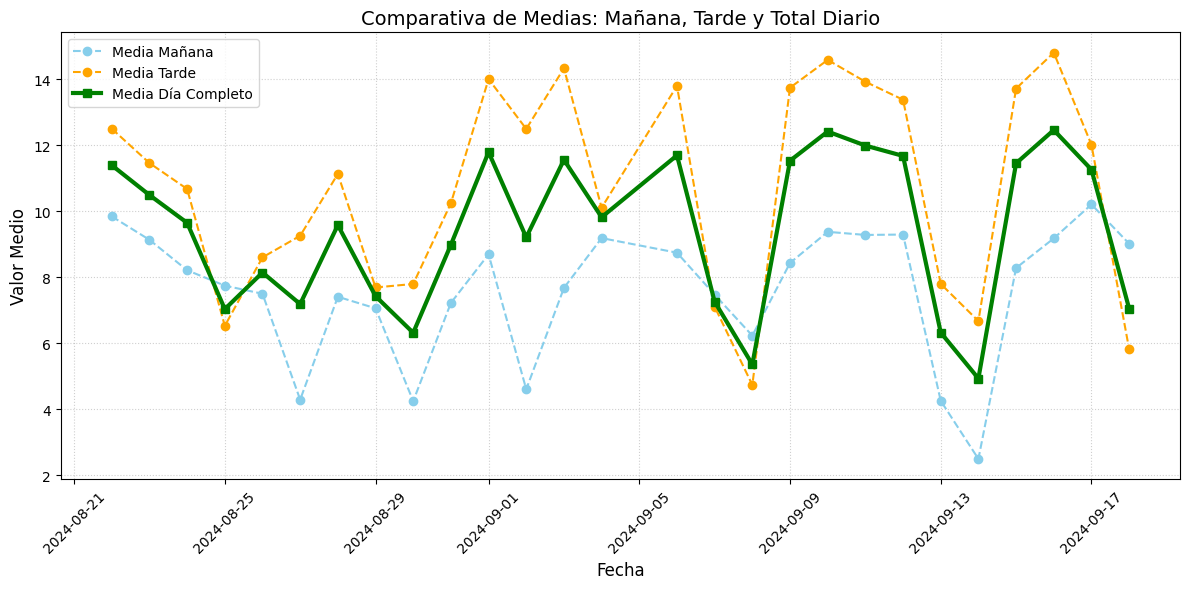

In [ ]:
plt.figure(figsize=(12, 6))

fecha_limite = pd.to_datetime('2027-09-05').date()
data_plot = pred_clas[pred_clas['dia'] <= fecha_limite]

plt.plot(data_plot['dia'], data_plot['mañana'], label='Media Mañana', color='skyblue', marker='o', linestyle='--')
plt.plot(data_plot['dia'], data_plot['tarde'], label='Media Tarde', color='orange', marker='o', linestyle='--')
plt.plot(data_plot['dia'], data_plot['media'], label='Media Día Completo', color='green', linewidth=3, marker='s')
plt.title('Comparativa de Medias: Mañana, Tarde y Total Diario', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor Medio', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

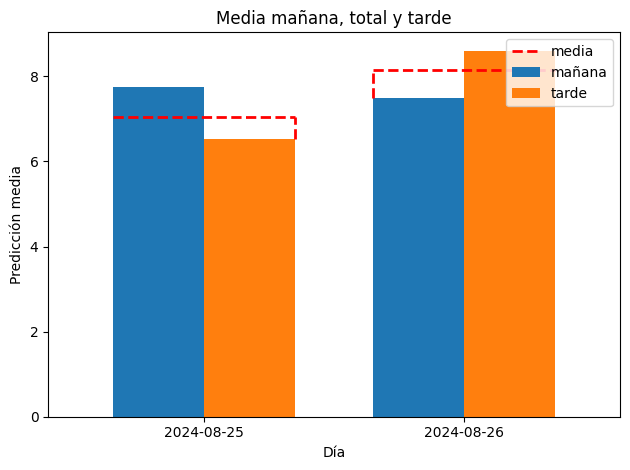

In [ ]:
fecha = '2024-08-25'

dia = pd.to_datetime(fecha).date()
dia_sig = (pd.to_datetime(fecha) + pd.Timedelta(days=1)).date()
dias = [dia, dia_sig]

data_plot = pred_clas[pred_clas['dia'].isin(dias)].copy()
data_plot = data_plot.set_index('dia')

ax = data_plot[['mañana', 'tarde']].plot(kind='bar', width=0.7)

bar_width = 0.35

for i, (idx, row) in enumerate(data_plot.iterrows()):
    media = row['media']
    if row['mañana'] < row['tarde']:
        min_val = row['mañana']
        x_pos = i - bar_width
    else:
        min_val = row['tarde']
        x_pos = i + bar_width
    
    ax.vlines(x=x_pos, ymin=min_val, ymax=media, 
              colors='red', linewidth=2, linestyles='dashed')
    
    ax.hlines(y=media, xmin=i-0.35, xmax=i+0.35, 
              colors='red', linewidth=2, linestyles='dashed',
              label='media' if i == 0 else '')

ax.set_xlabel('Día')
ax.set_ylabel('Predicción media')
ax.set_title('Media mañana, total y tarde')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Seleccionar día en concreto.

In [ ]:
fecha = pd.to_datetime('2024-08-25').date()

print(f"Media por la mañana del {fecha}: {pred_clas[pred_clas['dia'] == fecha]['mañana'].values[0]:.2f}")
print(f"Media por la tarde del {fecha}: {pred_clas[pred_clas['dia'] == fecha]['tarde'].values[0]:.2f}")
print(f"Media total del {fecha}: {pred_clas[pred_clas['dia'] == fecha]['media'].values[0]:.2f}")

Media por la mañana del 2024-08-25: 7.75
Media por la tarde del 2024-08-25: 6.53
Media total del 2024-08-25: 7.04


Predecir CTC con el modelo de Lorca

In [ ]:
import warnings
warnings.simplefilter(action='ignore')

dataCTC = pd.read_csv( #Cargar el csv
        'CTC_processed.csv',
        sep=";",
        low_memory=False,
)
dataCTC["datetime"] = pd.to_datetime(dataCTC["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
dataCTC["month"] = dataCTC["datetime"].dt.month
dataCTC["day"] = dataCTC["datetime"].dt.day
dataCTC["hour"] = dataCTC["datetime"].dt.hour
dataCTC["minute"] = dataCTC["datetime"].dt.minute

dataCTC.drop(columns=["datetime"], inplace=True)

exogenasCTC = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure','month', 'day', 'hour', 'minute', 'irr_ideal'] 

IRR_MAX_CTC = dataCTC["solarRad"].max() #maxima solarRad
dataCTC["irr_ideal"] = IRR_MAX_CTC * irr_ideal_norm

dataCTC.index = range(1555, 1555 + len(dataCTC))
predLorca = forecaster.predict(steps=len(dataCTC), exog=dataCTC[exogenasCTC])

In [ ]:
mae = mean_absolute_error(dataCTC['Power_gen'], predLorca)
mse = mean_squared_error(dataCTC['Power_gen'], predLorca)
rmse = np.sqrt(mse)
r2 = r2_score(dataCTC['Power_gen'], predLorca)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 85.8118
Mean Squared Error (MSE): 29948.4738
Root Mean Squared Error (RMSE): 173.0563
Coeficiente de determinación (R^2): -0.2140


Resumen del modelo

In [ ]:
forecaster.summary()

ForecasterRecursive 
Estimator: XGBRegressor 
Lags: [1 2 3] 
Window features: ['roll_mean_10', 'roll_min_10', 'roll_max_10'] 
Window size: 10 
Series name: Power_gen 
Exogenous included: True 
Exogenous names: 
    temperature, solarRad, humedad, windSpeed, rain, pressure, month, day, hour,
    minute, irr_ideal 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 1554] 
Training index type: RangeIndex 
Training index frequency: 1 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': 'cpu', 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.01